In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('ticks', rc={"axes.facecolor": (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']

pd.set_option('display.max_columns', None)

In [79]:
amr_ec = pd.read_csv("../data/ecoli/summary_matches.txt", sep="\t")
amr_pa = pd.read_csv("../data/paeruginosa/summary_matches.txt", sep="\t")

<ipython-input-79-3040eb6682c5>:1: DtypeWarning: Columns (35,39,40,41) have mixed types. Specify dtype option on import or set low_memory=False.
  amr_ec = pd.read_csv("../data/ecoli/summary_matches.txt", sep="\t")


In [80]:
def transform_amr_df(df):
    """
    Transforms an AMR category DataFrame into a binary matrix (0/1) indicating the presence of resistance genes.
    Adds an "MDR" column with 1 if three or more antibiotic classes (excluding "Efflux" and "ESBL (AmpC type)") have resistance.
    
    Parameters:
    df (pd.DataFrame): DataFrame with AMR categories as columns and resistance genes as values.
    
    Returns:
    pd.DataFrame: Transformed DataFrame with 0s and 1s, including an "MDR" column.
    """
    # Convert all values to string to handle NaN values correctly
    df_binary = df.iloc[:, 1:].notna().astype(int)
    
    # Add back the first two columns (sample identifiers)
    df_binary.insert(0, df.columns[0], df.iloc[:, 0])

    # Define antibiotic classes to exclude from MDR calculation
    excluded_classes = {"Efflux", "ESBL (AmpC type)", "Colistin", "Fosfomycin"}
    
    # Identify the relevant antibiotic classes for MDR classification
    relevant_columns = [col for col in df_binary.columns[1:] if col not in excluded_classes]

    # Compute MDR: If an isolate is resistant to 3 or more antibiotic classes, classify as MDR (1)
    df_binary["MDR"] = (df_binary[relevant_columns].sum(axis=1) >= 3).astype(int)

    return df_binary

In [81]:
amrec = transform_amr_df(amr_ec)
amrpa = transform_amr_df(amr_pa)

In [82]:
amrec

,Isolate,Fosfomycin,Efflux,Colistin,ESBL (AmpC type),Beta-lactamase (not ESBL or carbapenemase),Streptomycin,Sulfonamide,Trimethoprim,Tetracycline,Macrolide,Quinolone,Ampicillin/Chloramphenicol/Quinolone/Rifampin/Tetracycline,Other antimicrobial,Beta-lactamase (narrow-spectrum),ESBL,Quinolone/Triclosan,Chloramphenicol/Florfenicol,Lincosamides,Nitrofurantoin,Aztreonam,Chloramphenicol,Kanamycin,Amikacin/Kanamycin/Tobramycin,Carbapenemase (MBL),Aminoglycosides (Ribosomal methyltransferase),Rifamycin,Amikacin/Kanamycin/Tobramycin/Quinolone,Carbapenemase,Gentamicin,Gentamicin/Kanamycin/Tobramycin,Other aminoglycoside resistance (non-RMT),Gentamicin/Tobramycin/Apramycin,Beta-lactamase (unknown spectrum),Amikacin/Kanamycin,Azithromycin/Clarithromycin/Erythromycin,Isoniazid/Triclosan,Lincosamide/Macrolide/Streptogramin,Phenicol/Quinolone,Streptomycin/Spectinomycin,Erythromycin,Aminocoumarin,MDR
0,1085_F1S1R3D1B1P5A03,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,1085_F1S1R3D1B1P5A05,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,1085_F1S1R3D1B1P5A06,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,1085_F1S1R3D1B1P5A09,1,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1085_F1S1R3D1B1P5A10,1,1,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24765,SRR9997955,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
24766,SRR9998284,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
24767,SRR9998287,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
24768,SRR9998311,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [91]:
def resistance_score(df):
    df_sub = df.copy()
    df_sub["resistance_score"] = 0

    esbl_cols = ["Beta-lactamase (narrow-spectrum)", "ESBL", "Beta-lactamase (unknown spectrum)"]
    carbapenemase_cols = ["Carbapenemase", "Carbapenemase (MBL)"]
    colistin_cols = ["Colistin"]
    
    # Score 3: ESBL + colistin resistance
    mask3 = (df[esbl_cols].sum(axis=1) > 0) & (df[colistin].sum(axis=1) > 0)
    df_sub.loc[mask3, "resistance_score"] = 3

    # Score 2: Carbapenemase only
    mask2 = (df[carbapenemase_cols].sum(axis=1) > 0) & (df[colistin].sum(axis=1) == 0) & (df_sub["resistance_score"] < 3)
    df_sub.loc[mask2, "resistance_score"] = 2

    # Score 1: ESBL only
    mask1 = (df[esbl_cols].sum(axis=1) > 0) & (df[carbapenemase_cols].sum(axis=1) == 0) & (df_sub["resistance_score"] < 2)
    df_sub.loc[mask1, "resistance_score"] = 1

    return df_sub[["Isolate", "resistance_score"]]

In [84]:
score_ec = resistance_score_ec(amrec)

In [85]:
score_pa = resistance_score(amrpa)

In [93]:
score_ec.to_csv("../data/ecoli_resistance_score.tsv", sep="\t")
score_pa.to_csv("../data/paeruginosa_resistance_score.tsv", sep="\t")

In [86]:
score_binary_ec = score_ec['resistance_score'].astype(pd.CategoricalDtype(categories=[0, 1, 2, 3]))
score_binary_ec = pd.get_dummies(score_binary_ec, prefix="score")
score_binary_ec.index = score_ec.Isolate

In [87]:
score_binary_pa = score_pa['resistance_score'].astype(pd.CategoricalDtype(categories=[0, 1, 2, 3]))
score_binary_pa = pd.get_dummies(score_binary_pa, prefix="score")
score_binary_pa.index = score_pa.Isolate

In [88]:
sns.set_style('ticks', rc={"axes.facecolor": (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']

def plot_resistancescore_frequency(df_binary, name="", sp=""):
    """
    Plots the frequency of virulence factor presence by category as a bar plot.

    Parameters:
    df_binary (pd.DataFrame): Binary VF DataFrame with 0s and 1s (Isolates x Categories).
    """
    ordered_cols = [f"score_{i}" for i in range(6) if f"score_{i}" in df_binary.columns]
    vir_frequencies = df_binary[ordered_cols].sum()

    if len(df_binary) <= 10:
        print(f"Not enough isolates to plot: {len(df_binary)} (≤10). Skipping plot.")
        return

    if (vir_frequencies < 10).all():
        print("No virulence scores with frequency ≥10. Skipping plot.")
        return

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.barplot(
        x=vir_frequencies.index,
        y=vir_frequencies.values,
        order=ordered_cols,
        color='steelblue',
        alpha=0.6,
        ax=ax
    )

    ax.set_xlabel("Resistance Score")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{name}")
    ax.set_facecolor("white")
    ax.tick_params(axis='x', rotation=45)

    sns.despine()
    plt.tight_layout()
    plt.savefig(f"../out/amr_score_{sp}.svg", format="svg", dpi=150)
    plt.savefig(f"../out/amr_score_{sp}.png", format="png", dpi=150)
    plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

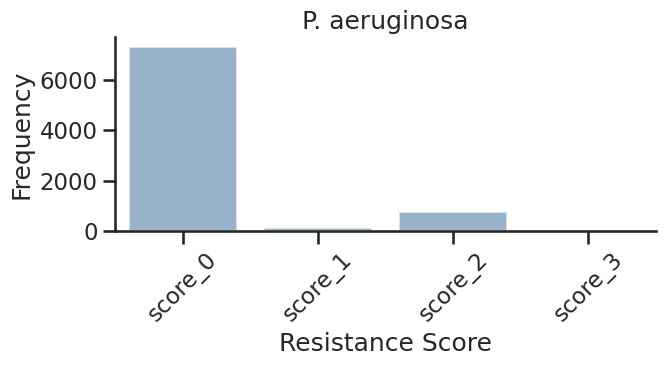

In [89]:
plot_resistancescore_frequency(score_binary_pa, name="P. aeruginosa", sp="pa")

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

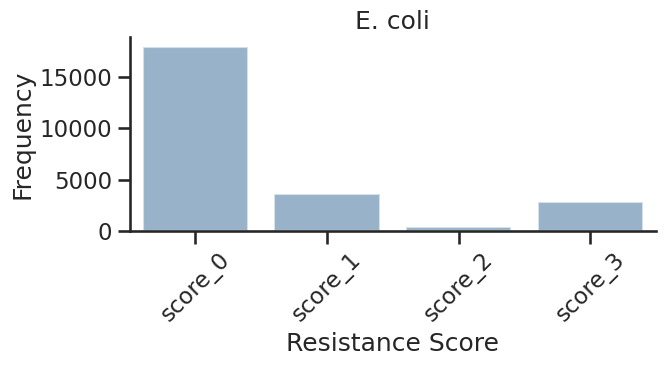

In [90]:
plot_resistancescore_frequency(score_binary_ec, name="E. coli", sp="ec")